# Graphing the Data
## Imports

In [1]:
import pandas as pd
import numpy as np

# Needed for Plotly
import plotly.express as px
import plotly.tools as tools
import plotly.graph_objects as go

# Needed for Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Run helpers and read in data

In [3]:
%run helpers.ipynb

In [4]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')

To plot all films at once regardless of nomination status, we use the columns as series to concatenate them into a data frame. This allows the budget and box office variables to be used as combined axes for Plotly Express.

In [5]:
oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

budget_nom = oscar_with_imdb['budget']
gross_nom = oscar_with_imdb['gross_worldwide']

budget_imdb = imdb_non_oscar['budget']
gross_imdb = imdb_non_oscar['gross_worldwide']

oscar_noms = pd.concat([budget_nom, gross_nom, oscar_with_imdb['Status']], axis=1)
non_noms = pd.concat([budget_imdb, gross_imdb, imdb_non_oscar['Status']], axis=1)

combined_films = pd.concat([oscar_noms, non_noms], axis=0)
combined_films.dropna(how='any', inplace=True)

In [6]:
# temp = combined_films.sort_values(['gross_worldwide'], ascending=True)
combined_films = combined_films[combined_films['budget'] >= 100]
combined_films = combined_films[combined_films['gross_worldwide'] >= 100]

In [7]:
# combined_films['budget'] = np.log10(combined_films['budget'])

## Setting up data for scatter plot (Budget vs Box Office)

We want to categorize films by their academy award status or if they were not nominated. We begin by adding False entries to the `Winner` field in the joined data frame for Academy Award films, and then dropping any NA values in both joined data frames.

### Create `Status` field

In [11]:
# Nominess are marked asz NaN so we replace with False
oscar_with_imdb['Winner'] = oscar_with_imdb['Winner'].fillna(False)
oscar_with_imdb.dropna(subset=['budget', 'gross_worldwide'], inplace=True)
imdb_non_oscar.dropna(subset=['budget', 'gross_worldwide'], inplace=True)

In [51]:
oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row else 'Nominated')

winners = oscar_with_imdb[oscar_with_imdb['Status'] == 'Winner']
nominees = oscar_with_imdb[oscar_with_imdb['Status'] == 'Nominated']
non_nom = imdb_non_oscar

all_films = [winners, nominees, non_nom]
to_graph = [None, None, None]
film_groups = ['Won', 'Nominated', 'Not Nominated']

### Round budget and box and budget

In [14]:
print([film.shape for film in all_films])

[(1321, 31), (3993, 31), (8758, 20)]


Round everything and add to graph

In [52]:
for i, df in enumerate(all_films):
    # ToDo check round_value function
    df['rounded_budget'] = df['budget'].copy().apply(round_value)
    df['rounded_gross'] = df['gross_worldwide'].apply(round_value)
    
    # Drop NA and zero values
    df = df.dropna(subset=['rounded_budget', 'rounded_gross'])
    df = df[(df['rounded_budget'] > 0) & (df['rounded_gross'] > 0)]
    
    # df['rounded_budget'] = df['rounded_budget']
    # df['rounded_gross'] = np.log10(df['rounded_gross'])
    # to_graph[i] = df.groupby(['rounded_budget', 'rounded_gross']).size().reset_index(name='count')
    to_graph[i] = df

In [53]:
print([film.shape for film in to_graph])

[(1137, 33), (3556, 33), (7425, 22)]


### Iterate through rows and add points to scatter plot

## NOTE: The data frames are already rounded by log10 along the x-axis!

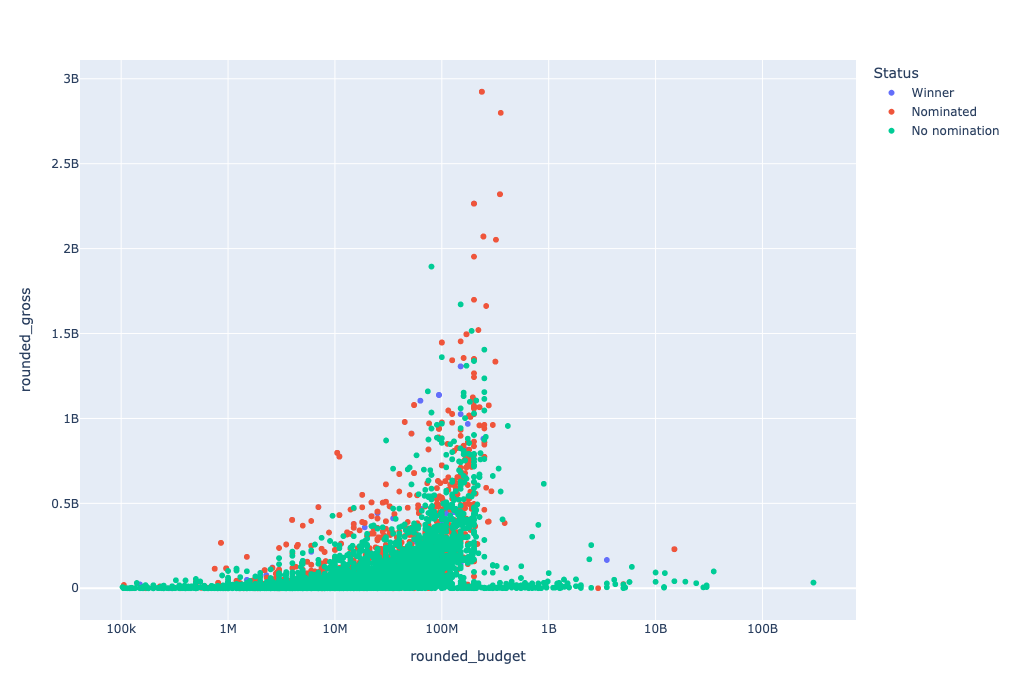

In [55]:
# x = combined_films['budget']
# y = combined_films['gross_worldwide']
df1 = to_graph[0]
df2 = to_graph[1]
df3 = to_graph[2]

all_films_scatter = pd.concat([df1, df2, df3], ignore_index=True)
fig = px.scatter(all_films_scatter, x='rounded_budget', y='rounded_gross', color='Status')
# fig = px.scatter(x, y, log_x=True, log_y=True)

fig.update_layout(xaxis=dict(type='log'))
# fig.update_layout(yaxis=dict(type='log'))
fig.update_layout(height=700)
fig.show(config={'displayModeBar': False})

In [50]:
# ToDo: Add scatter for revenue and color code profitability